In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/llm_requests.csv")

In [3]:
df.head()

,model,input_tokens,output_tokens,concurrent_requests,region,latency_ms
0,large,202,809,5,us-east,2836
1,small,3116,154,9,us-east,1952
2,large,230,80,2,us-west,1773
3,small,2565,77,9,eu-west,2006
4,large,2972,608,7,eu-west,3536


In [4]:
df.shape

(500, 6)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   model                500 non-null    str  
 1   input_tokens         500 non-null    int64
 2   output_tokens        500 non-null    int64
 3   concurrent_requests  500 non-null    int64
 4   region               500 non-null    str  
 5   latency_ms           500 non-null    int64
dtypes: int64(4), str(2)
memory usage: 23.6 KB


In [6]:
df.describe()

,input_tokens,output_tokens,concurrent_requests,latency_ms
count,500.000000,500.000000,500.000000,500.000000
mean,2049.906000,534.558000,5.850000,2617.812000
std,1147.231934,267.903795,2.846701,642.318069
min,131.000000,51.000000,1.000000,1152.000000
25%,1069.750000,308.000000,3.000000,2160.000000
50%,1933.500000,537.000000,6.000000,2591.000000
75%,3063.250000,747.750000,8.000000,3064.500000
max,3994.000000,999.000000,10.000000,4246.000000


In [7]:
df.isna().sum()

model                  0
input_tokens           0
output_tokens          0
concurrent_requests    0
region                 0
latency_ms             0
dtype: int64

In [8]:
df["model"].value_counts()

model
medium    179
large     165
small     156
Name: count, dtype: int64

In [9]:
df["region"].value_counts()

region
eu-west    175
us-east    167
us-west    158
Name: count, dtype: int64

## Initial findings

- The dataset contains 500 observations and 6 columns.
- No missing values were found.
- `model` and `region` are categorical features.
- `input_tokens`, `output_tokens`, and `concurrent_requests` are numerical features.
- `latency_ms` is the regression target.
- Model and region categories are reasonably balanced.
- Latency ranges from approximately 1.1s to 4.2s.

In [11]:
X = df.drop(columns=["latency_ms"])
y = df["latency_ms"]

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 5)
(100, 5)
(400,)
(100,)


In [15]:
X_train.head()

,model,input_tokens,output_tokens,concurrent_requests,region
249,large,1962,427,5,us-east
433,small,2208,528,8,us-west
19,medium,964,985,10,us-east
322,medium,2020,502,5,us-east
332,small,1627,989,5,us-west


In [16]:
numerical_features = [
    "input_tokens",
    "output_tokens",
    "concurrent_requests"
]

categorical_features = [
    "model",
    "region"
]

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [18]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            "num",
            StandardScaler(),
            numerical_features,
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [19]:
X_train_preprocessed = preprocessor.fit_transform(X_train)

In [20]:
X_test_preprocessed = preprocessor.transform(X_test)

In [21]:
print(X_train.shape)
print(X_train_preprocessed.shape)

print(X_test.shape)
print(X_test_preprocessed.shape)

(400, 5)
(400, 7)
(100, 5)
(100, 7)


In [22]:
preprocessor.get_feature_names_out()

array(['num__input_tokens', 'num__output_tokens',
       'num__concurrent_requests', 'cat__model_medium',
       'cat__model_small', 'cat__region_us-east', 'cat__region_us-west'],
      dtype=object)

In [23]:
scaler = preprocessor.named_transformers_["num"]

# mean_ and scale_ were learned from X_train during fit().
# They will be reused to transform X_test and any future data.
print(scaler.mean_)
print(scaler.scale_)

[2046.45    531.7275    5.9675]
[1147.24339506  267.14375015    2.83926817]


### What did StandardScaler learn?

`scaler.mean_` contains the mean value learned from the training set for each numerical feature:

- `input_tokens`
- `output_tokens`
- `concurrent_requests`

`scaler.scale_` contains the scale learned for each feature, approximately its standard deviation.

For every new numerical value, StandardScaler applies:

scaled_value = (value - mean) / scale

Important: these values are learned only from `X_train`.

When transforming `X_test` or new production data, the scaler reuses these same learned values instead of calculating new ones.

In [25]:
encoder = preprocessor.named_transformers_["cat"]

print(encoder.categories_)

[array(['large', 'medium', 'small'], dtype=object), array(['eu-west', 'us-east', 'us-west'], dtype=object)]


### What did OneHotEncoder learn?

The encoder learned the categorical values present in the training data.

For `model`:

- `large`
- `medium`
- `small`

For `region`:

- `eu-west`
- `us-east`
- `us-west`

Because `drop="first"` is enabled, one category from each feature is used as the reference category.

The transformed categorical features are:

- `model_medium`
- `model_small`
- `region_us-east`
- `region_us-west`

The reference categories are therefore:

- `model = large`
- `region = eu-west`

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
linear_model = LinearRegression()

In [29]:
linear_model.fit(X_train_preprocessed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 220.11, 320.49, 280.83,...,-1009.61, -199.16, -91.11]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3243
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[21.3 ,19.57,19.14,...,10.27, 6.93, 6.41]"


In [30]:
linear_model.intercept_

np.float64(3243.398936013445)

In [31]:
linear_model.coef_

array([  220.11466041,   320.48935316,   280.82826332,  -586.78401156,
       -1009.61260591,  -199.1603483 ,   -91.10553952])

### What did Linear Regression learn?

`linear_model.intercept_` is the base value of the learned linear equation.

`linear_model.coef_` contains the weight learned for each transformed feature.

Conceptually, the model predicts:

predicted_y =
intercept
+ coefficient_1 × feature_1
+ coefficient_2 × feature_2
+ ...
+ coefficient_n × feature_n

The coefficients represent how each feature contributes to the final prediction.

In [33]:
feature_names = preprocessor.get_feature_names_out()

In [34]:
for feature, coefficient in zip(
    feature_names,
    linear_model.coef_
):
    print(f"{feature}: {coefficient:.2f}")

num__input_tokens: 220.11
num__output_tokens: 320.49
num__concurrent_requests: 280.83
cat__model_medium: -586.78
cat__model_small: -1009.61
cat__region_us-east: -199.16
cat__region_us-west: -91.11


### Learned equation

For this trained model, the prediction is approximately:

ŷ =
3243.40

+ 220.11 × input_tokens_scaled
+ 320.49 × output_tokens_scaled
+ 280.83 × concurrent_requests_scaled

- 586.78 × model_medium
- 1009.61 × model_small

- 199.16 × region_us-east
- 91.11 × region_us-west

The numerical features are scaled values, while categorical features are binary values produced by OneHotEncoder.

In [36]:
print(f"Intercept: {linear_model.intercept_:.2f}")

Intercept: 3243.40


In [37]:
y_pred = linear_model.predict(X_test_preprocessed)

In [38]:
y_pred[:5]

array([2636.22909608, 2052.02808145, 1888.02023347, 2138.05604098,
       3207.1574822 ])

In [39]:
y_test.head()

361    2797
73     2006
374    2092
155    2113
104    3306
Name: latency_ms, dtype: int64

### Prediction flow

For a new request:

1. Numerical features are transformed using the `mean_` and `scale_` learned from `X_train`.
2. Categorical features are transformed using the categories learned by `OneHotEncoder`.
3. The transformed features are passed to `LinearRegression`.
4. The model multiplies every feature by its learned coefficient.
5. All contributions are added to the learned intercept.
6. The final result is the predicted `latency_ms`.

In short:

- `mean_` + `scale_` → prepare numerical data
- OneHotEncoder categories → prepare categorical data
- `intercept_` + `coef_` → calculate the prediction

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [42]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} ms")
print(f"RMSE: {rmse: .2f} ms")
print(f"R2: {r2:.4f}")

MAE: 98.94 ms
RMSE:  114.20 ms
R2: 0.9608


In [43]:
residuals = y_test - y_pred

residuals[:5]

361    160.770904
73     -46.028081
374    203.979767
155    -25.056041
104     98.842518
Name: latency_ms, dtype: float64

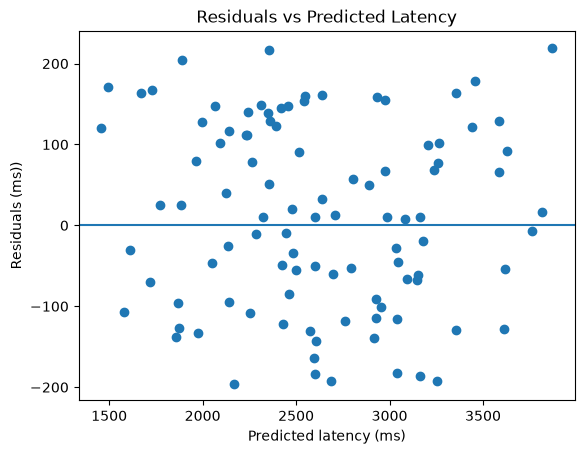

In [44]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted latency (ms)")
plt.ylabel("Residuals (ms))")
plt.title("Residuals vs Predicted Latency")
plt.show()

### Residual analysis

The residuals are distributed approximately around zero without an obvious
systematic pattern.

There is no clear curve, trend, or strong increase in residual variance as
predicted latency changes.

This suggests that the linear model captures the underlying relationship
between the features and `latency_ms` reasonably well.

The remaining error is expected because the synthetic dataset includes
random noise between approximately -200 ms and +200 ms.

In [46]:
residuals.mean()

np.float64(11.763744354700439)